# DNN surrogate 기반 1,000개 설계 탐색

FEMM으로 해석한 50개 DOE를 학습 데이터로 사용해 3개 은닉층 DNN surrogate를 만들고,
형상검사를 통과한 새로운 1,000개 설계의 평균토크와 절대 토크리플을 예측한다.

> **주의:** 학습점이 50개뿐이므로 DNN의 예측값은 FEMM 결과가 아니다.
> 반복 교차검증과 앙상블 표준편차를 함께 확인하고, 최종 후보는 반드시 FEMM으로 재해석해야 한다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import qmc
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from generate_axis_shortedge_doe_previews import RANGES, evaluate_row

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Glyph .* missing")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5.5)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path.cwd()
if not (ROOT / "doe_axis_shortedge_results").exists():
    ROOT = Path("C:/Users/139/Documents/pyFEMM 2")
RESULT_DIR = ROOT / "doe_axis_shortedge_results"
SUMMARY_CSV = RESULT_DIR / "axis_shortedge_ccf_summary.csv"

df = pd.read_csv(SUMMARY_CSV)
factors = ["magnet_thickness_mm", "magnet_length_mm", "v_angle_deg", "tip_gap_mm"]
factor_labels = ["Thickness", "Length", "V angle", "TIPGAP"]
targets = ["loaded_torque_mean_Nm", "loaded_torque_pkpk_Nm"]
X = df[factors].to_numpy()
y = df[targets].to_numpy()

print(f"Training designs: {len(df)}")
display(df[factors + targets].describe().T)

Training designs: 50


,count,mean,std,min,25%,50%,75%,max
magnet_thickness_mm,50.0000,3.8938,0.8209,2.5139,3.2117,3.9280,4.5764,5.4498
magnet_length_mm,50.0000,14.1091,1.4705,12.0737,12.8450,14.0197,15.2785,16.7881
v_angle_deg,50.0000,63.2763,15.8806,35.6190,51.1816,63.1099,75.9667,89.7589
tip_gap_mm,50.0000,2.4037,1.2638,0.5108,1.2866,2.3600,3.6238,4.4628
loaded_torque_mean_Nm,50.0000,34.0774,10.3803,8.0698,29.5616,35.6127,40.4354,51.0658
loaded_torque_pkpk_Nm,50.0000,8.2417,2.5730,3.0458,6.2725,8.1359,9.9113,14.6074


## 1. DNN 구조와 반복 교차검증

- 입력: Thickness, Length, V angle, TIPGAP
- 출력: 평균토크, 토크리플 pk-pk
- 은닉층: 32–16–8, `tanh`
- 정규화: 입력과 출력 모두 표준화
- 검증: 5-fold × 5회 반복

50점에서 과도하게 큰 네트워크를 쓰면 학습점을 외우기 쉬우므로 L2 규제를 적용했다.

,CV R2,CV RMSE
Mean torque [Nm],0.9619,2.0064
Ripple pk-pk [Nm],0.8815,0.8767


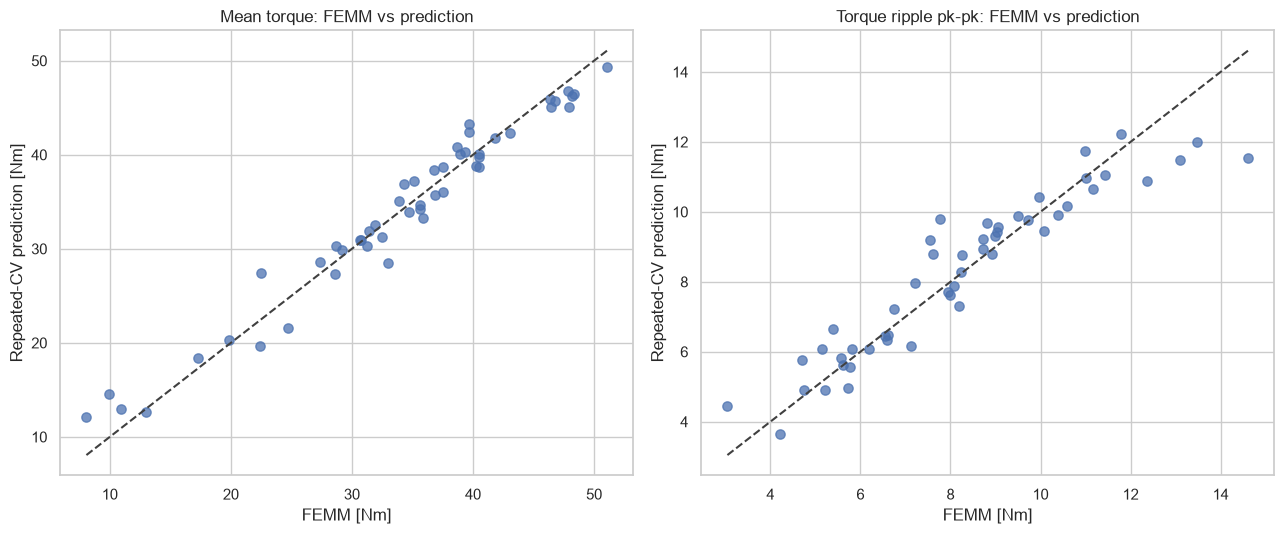

In [2]:
def make_model(seed):
    network = Pipeline([
        ("scale_x", StandardScaler()),
        ("dnn", MLPRegressor(
            hidden_layer_sizes=(32, 16, 8),
            activation="tanh",
            solver="lbfgs",
            alpha=1.0,
            max_iter=4000,
            random_state=seed,
        )),
    ])
    return TransformedTargetRegressor(regressor=network, transformer=StandardScaler())

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=20260730)
pred_sum = np.zeros_like(y, dtype=float)
pred_count = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    model = make_model(1000 + fold)
    model.fit(X[train_idx], y[train_idx])
    pred_sum[test_idx] += model.predict(X[test_idx])
    pred_count[test_idx] += 1

cv_pred = pred_sum / pred_count[:, None]
metrics = pd.DataFrame({
    "CV R2": [
        r2_score(y[:, 0], cv_pred[:, 0]),
        r2_score(y[:, 1], cv_pred[:, 1]),
    ],
    "CV RMSE": [
        root_mean_squared_error(y[:, 0], cv_pred[:, 0]),
        root_mean_squared_error(y[:, 1], cv_pred[:, 1]),
    ],
}, index=["Mean torque [Nm]", "Ripple pk-pk [Nm]"])
display(metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for j, (title, unit) in enumerate([
    ("Mean torque", "Nm"),
    ("Torque ripple pk-pk", "Nm"),
]):
    axes[j].scatter(y[:, j], cv_pred[:, j], s=45, alpha=0.75)
    lo = min(y[:, j].min(), cv_pred[:, j].min())
    hi = max(y[:, j].max(), cv_pred[:, j].max())
    axes[j].plot([lo, hi], [lo, hi], "--", color="0.25")
    axes[j].set(xlabel=f"FEMM [{unit}]", ylabel=f"Repeated-CV prediction [{unit}]",
                title=f"{title}: FEMM vs prediction")
plt.tight_layout()
plt.show()

## 2. 형상검사를 통과한 LHS 후보 1,000개 생성

기존 DOE와 같은 변수 범위를 사용한다.

- Thickness: 2.5–5.5 mm
- Length: 12.0–16.8 mm
- V angle: 35–90°
- TIPGAP: 0.5–4.5 mm

실제 자석 다각형을 만든 뒤 외측 브리지, 축 여유, 인접극 자석 간격을 검사한다.

In [3]:
rng_seed = 20260731
sampler = qmc.LatinHypercube(d=4, seed=rng_seed, optimization="random-cd")
valid_rows = []
tested = 0

while len(valid_rows) < 1000:
    unit = sampler.random(1200)
    lower = np.array([RANGES[name][0] for name in factors])
    upper = np.array([RANGES[name][1] for name in factors])
    values_batch = qmc.scale(unit, lower, upper)
    for values in values_batch:
        tested += 1
        row = evaluate_row(
            tested,
            {name: float(value) for name, value in zip(factors, values)},
        )
        if row["geometry_status"] == "OK":
            valid_rows.append(row)
            if len(valid_rows) == 1000:
                break

candidates = pd.DataFrame(valid_rows)
candidates["candidate"] = np.arange(1, len(candidates) + 1)
print(f"Tested {tested} points; accepted {len(candidates)} valid geometries")
display(candidates[factors + [
    "actual_tip_gap_mm", "outer_bridge_min_mm", "shaft_clearance_min_mm",
    "adjacent_pole_gap_min_mm"
]].describe().T)

Tested 1152 points; accepted 1000 valid geometries


,count,mean,std,min,25%,50%,75%,max
magnet_thickness_mm,1000.0000,3.9195,0.8559,2.5002,3.1805,3.8891,4.6211,5.4982
magnet_length_mm,1000.0000,14.2024,1.3340,12.0005,13.0573,14.1196,15.3053,16.7965
v_angle_deg,1000.0000,63.7469,14.5981,35.0482,51.9052,64.0984,75.7775,89.9650
tip_gap_mm,1000.0000,2.4538,1.1543,0.5040,1.4461,2.4198,3.4416,4.4989
actual_tip_gap_mm,1000.0000,2.4538,1.1543,0.5040,1.4461,2.4198,3.4416,4.4989
outer_bridge_min_mm,1000.0000,3.4405,1.3344,1.0025,2.3791,3.3539,4.4776,7.1172
shaft_clearance_min_mm,1000.0000,5.8173,1.6774,2.6807,4.4448,5.6777,7.1331,10.0070
adjacent_pole_gap_min_mm,1000.0000,8.5746,4.5234,0.0232,4.8868,8.3420,12.4349,18.6206


## 3. DNN 앙상블 예측

초기값이 다른 DNN 30개를 전체 50점에 각각 학습한다.
30개 예측의 평균을 surrogate 예측값으로, 표준편차를 모델 불확실성 지표로 사용한다.

In [4]:
n_ensemble = 30
candidate_X = candidates[factors].to_numpy()
ensemble_predictions = []

for seed in range(n_ensemble):
    model = make_model(2000 + seed)
    model.fit(X, y)
    ensemble_predictions.append(model.predict(candidate_X))

ensemble_predictions = np.stack(ensemble_predictions)
pred_mean = ensemble_predictions.mean(axis=0)
pred_std = ensemble_predictions.std(axis=0, ddof=1)

candidates["pred_mean_torque_Nm"] = pred_mean[:, 0]
candidates["pred_ripple_pkpk_Nm"] = pred_mean[:, 1]
candidates["unc_mean_torque_Nm"] = pred_std[:, 0]
candidates["unc_ripple_pkpk_Nm"] = pred_std[:, 1]

def pareto_mask(mean, ripple):
    keep = np.ones(len(mean), dtype=bool)
    for i in range(len(mean)):
        dominated = (
            (mean >= mean[i])
            & (ripple <= ripple[i])
            & ((mean > mean[i]) | (ripple < ripple[i]))
        )
        keep[i] = not dominated.any()
    return keep

candidates["predicted_pareto"] = pareto_mask(
    candidates["pred_mean_torque_Nm"].to_numpy(),
    candidates["pred_ripple_pkpk_Nm"].to_numpy(),
)

# 보수적 목적: 평균토크는 1σ 차감, 리플은 1σ 가산
candidates["conservative_mean_Nm"] = (
    candidates["pred_mean_torque_Nm"] - candidates["unc_mean_torque_Nm"]
)
candidates["conservative_ripple_Nm"] = (
    candidates["pred_ripple_pkpk_Nm"] + candidates["unc_ripple_pkpk_Nm"]
)
candidates["conservative_pareto"] = pareto_mask(
    candidates["conservative_mean_Nm"].to_numpy(),
    candidates["conservative_ripple_Nm"].to_numpy(),
)

pred_pareto = candidates[candidates["predicted_pareto"]].copy()
print(f"Predicted Pareto designs: {len(pred_pareto)} / 1000")
print(f"Conservative Pareto designs: {candidates['conservative_pareto'].sum()} / 1000")

Predicted Pareto designs: 24 / 1000
Conservative Pareto designs: 24 / 1000


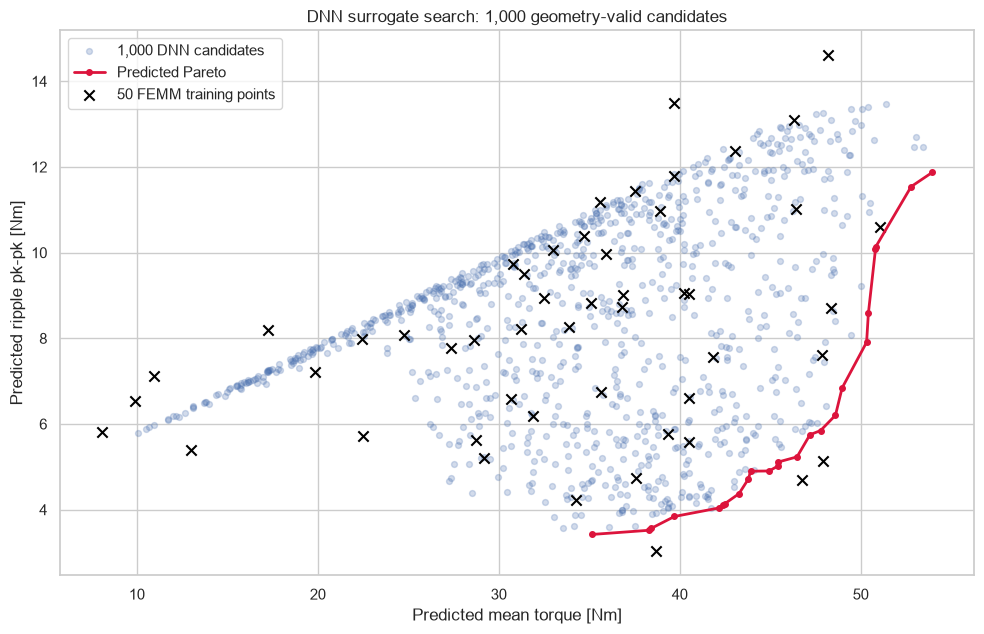

예측 파레토 중 균형점 상위 20개


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,tip_gap_mm,magnet_center_offset_deg,outer_bridge_min_mm,adjacent_pole_gap_min_mm,pred_mean_torque_Nm,unc_mean_torque_Nm,pred_ripple_pkpk_Nm,unc_ripple_pkpk_Nm,conservative_mean_Nm,conservative_ripple_Nm
candidate,,,,,,,,,,,,,
625,4.8869,16.6191,81.2154,0.6075,24.5450,3.5520,1.0128,48.6037,0.2491,6.2029,0.0910,48.3546,6.2939
361,5.1202,16.3322,80.0992,1.6464,25.6308,3.3641,0.5316,47.7800,0.2648,5.8458,0.0603,47.5152,5.9061
708,4.4685,16.6950,81.2796,1.3425,25.8001,3.6047,0.4080,46.4801,0.2699,5.2315,0.0642,46.2102,5.2957
482,5.4560,15.6676,84.3098,1.1261,24.0616,4.0152,0.8492,47.1951,0.2398,5.7488,0.0804,46.9553,5.8292
636,4.7088,16.7821,74.6008,1.6123,25.7184,2.7954,1.7955,48.9714,0.2476,6.8402,0.0780,48.7237,6.9182
419,4.5769,16.1969,82.8395,1.5389,25.4357,3.9304,0.5316,45.4275,0.2280,5.0188,0.0645,45.1994,5.0832
587,4.3551,16.2881,83.6441,0.8665,24.5799,4.1381,1.0347,45.4411,0.1895,5.1118,0.0624,45.2516,5.1742
921,4.4763,16.2145,81.4141,2.0557,26.1795,3.7619,0.4005,44.9383,0.2365,4.9023,0.0632,44.7018,4.9656
541,4.0221,16.0545,86.0357,0.5782,23.8747,4.6624,1.3857,43.7927,0.1801,4.7154,0.0615,43.6127,4.7770


In [5]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(candidates.loc[~candidates.predicted_pareto, "pred_mean_torque_Nm"],
           candidates.loc[~candidates.predicted_pareto, "pred_ripple_pkpk_Nm"],
           s=18, alpha=0.25, label="1,000 DNN candidates")
front = pred_pareto.sort_values("pred_mean_torque_Nm")
ax.plot(front["pred_mean_torque_Nm"], front["pred_ripple_pkpk_Nm"],
        "-o", color="crimson", ms=4, lw=2, label="Predicted Pareto")
ax.scatter(df["loaded_torque_mean_Nm"], df["loaded_torque_pkpk_Nm"],
           marker="x", s=55, color="black", label="50 FEMM training points")
ax.set(xlabel="Predicted mean torque [Nm]",
       ylabel="Predicted ripple pk-pk [Nm]",
       title="DNN surrogate search: 1,000 geometry-valid candidates")
ax.legend()
plt.tight_layout()
plt.show()

# 이상점에 치우치지 않는 파레토 균형점: 예측 파레토 내부에서 ideal까지 정규화 거리
for col in ["pred_mean_torque_Nm", "pred_ripple_pkpk_Nm"]:
    span = front[col].max() - front[col].min()
    if col == "pred_mean_torque_Nm":
        front[col + "_loss"] = (front[col].max() - front[col]) / span
    else:
        front[col + "_loss"] = (front[col] - front[col].min()) / span
front["ideal_distance"] = np.hypot(
    front["pred_mean_torque_Nm_loss"],
    front["pred_ripple_pkpk_Nm_loss"],
)

result_cols = [
    "candidate", *factors,
    "magnet_center_offset_deg", "outer_bridge_min_mm", "adjacent_pole_gap_min_mm",
    "pred_mean_torque_Nm", "unc_mean_torque_Nm",
    "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm",
    "conservative_mean_Nm", "conservative_ripple_Nm",
]
print("예측 파레토 중 균형점 상위 20개")
display(front.sort_values("ideal_distance").set_index("candidate")[result_cols[1:]].head(20))

## 4. 후보별 예측과 불확실성

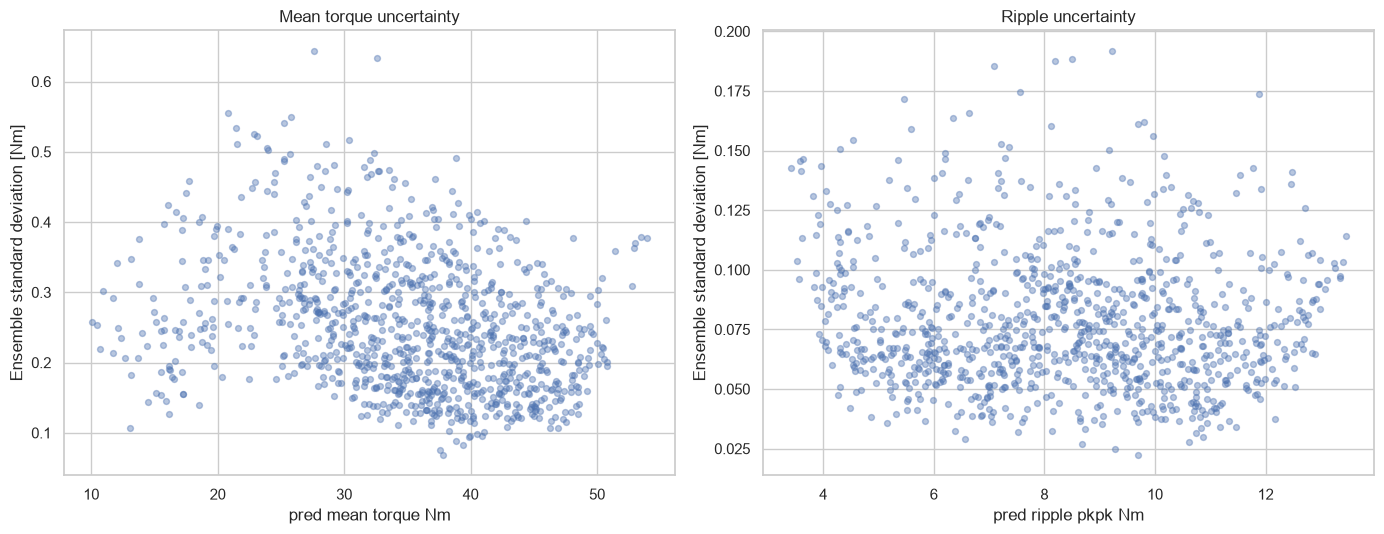

Saved: C:\Users\139\Documents\pyFEMM 2\axis_shortedge_dnn_candidates_1000.csv
Saved: C:\Users\139\Documents\pyFEMM 2\axis_shortedge_dnn_predicted_pareto.csv


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, xcol, ycol, title in [
    (axes[0], "pred_mean_torque_Nm", "unc_mean_torque_Nm", "Mean torque uncertainty"),
    (axes[1], "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm", "Ripple uncertainty"),
]:
    ax.scatter(candidates[xcol], candidates[ycol], s=18, alpha=0.4)
    ax.set(xlabel=xcol.replace("_", " "), ylabel="Ensemble standard deviation [Nm]",
           title=title)
plt.tight_layout()
plt.show()

candidate_csv = ROOT / "axis_shortedge_dnn_candidates_1000.csv"
pareto_csv = ROOT / "axis_shortedge_dnn_predicted_pareto.csv"
candidates.to_csv(candidate_csv, index=False)
front.sort_values("ideal_distance").to_csv(pareto_csv, index=False)
print(f"Saved: {candidate_csv}")
print(f"Saved: {pareto_csv}")

## 5. 결과를 사용할 때의 기준

1. 교차검증 `R²`가 낮거나 RMSE가 크면 DNN 파레토를 최적해로 해석하지 않는다.
2. 앙상블 표준편차가 큰 후보보다 예측값이 조금 낮아도 불확실성이 작은 후보를 우선한다.
3. 균형점 상위 후보를 서로 너무 가까운 형상끼리 중복 선정하지 않는다.
4. 최종 5–10개 후보는 반드시 FEMM 0.5° 스윕으로 재해석한다.
5. FEMM 검증점이 추가되면 50점 학습자료에 합쳐 surrogate를 다시 학습한다.

## Standardized Research Conclusion
<!-- STANDARDIZED_RESEARCH_CONCLUSION -->

**Research Question.** 50개 FEMM으로 학습한 DNN이 미해석 후보를 선별할 수 있는가?

**Answer.** 후보 선별에는 유효하다. CV R²는 평균토크 0.962, 리플 0.882였지만 1,000개 예측값은 FEMM 결과가 아니다.

**Evidence.** 형상검사 통과 영역에서 토크–리플 Pareto 후보를 생성했다.

**Limitation.** 50점 학습자료의 희소영역·경계 예측은 불확실하다.

**Next Step.** Pareto 대표점을 FEMM 검증하고 학습자료에 추가한다.